In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"deshmukhsanyukta","key":"eb61d531dbb683d87d2b5ac475b0bb4d"}'}

In [6]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d awsaf49/coco-2017-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/coco-2017-dataset
License(s): CC-BY-SA-4.0
100% 25.0G/25.0G [02:28<00:00, 181MB/s]



In [8]:
!unzip -q coco-2017-dataset.zip

In [10]:
train_img_dir = "train2017"
train_ann_file = "annotations/instances_train2017.json"

In [18]:
import os
from pycocotools.coco import COCO

# auto-find paths
base = "/kaggle/input"
train_ann_file, train_img_dir = None, None

for root, dirs, files in os.walk(base):
    if "instances_train2017.json" in files:
        train_ann_file = os.path.join(root, "instances_train2017.json")
    if root.endswith("train2017"):
        train_img_dir = root

# correct dataset call (FIXED)
train_ds = COCOSubjectDataset(
    annotation_file=train_ann_file,
    img_dir=train_img_dir,
    transform=None
)

print("Dataset loaded successfully")

Dataset loaded successfully


In [21]:
train_ann_file = "/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_train2017.json"
train_img_dir = "/kaggle/input/coco-2017-dataset/coco2017/train2017"

In [24]:
from pycocotools.coco import COCO

coco = COCO(train_ann_file)

train_ds = COCOSubjectDataset(
    annotation_file=train_ann_file,
    img_dir=train_img_dir,
    transform=None
)

print("Working successfully")

Working successfully


In [8]:
import os
from pycocotools.coco import COCO

data_dir="/content/coco2017"
ann_file=os.path.join(data_dir, "annotations/instances_train2017.json")
coco=COCO(ann_file)

loading annotations into memory...
Done (t=22.63s)
creating index...
index created!


In [12]:
# Install albumentations if not already installed
!pip install -q albumentations

import os
import cv2
import torch
import numpy as np # Import numpy for mask operations
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_ann_file = "/content/coco2017/annotations/instances_train2017.json"
train_img_dir = "/content/coco2017/train2017"

coco2017 = COCO(train_ann_file)
train_ids = list(coco2017.imgs.keys())

class COCOSubjectDataset(Dataset):
    def __init__(self, coco, img_dir, img_ids, transform=None):
        self.coco = coco
        self.img_dir = img_dir
        self.image_ids = img_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=None) # Get all annotations
        anns = self.coco.loadAnns(ann_ids)

        # Create an empty mask for the image
        height, width = img_info['height'], img_info['width']
        mask = np.zeros((height, width), dtype=np.uint8)

        # Iterate over annotations and combine masks into a single binary mask
        for ann in anns:
            current_mask = self.coco.annToMask(ann)
            mask = np.maximum(mask, current_mask) # Combine masks by taking the maximum

        if self.transform:
            # Albumentations expects mask for segmentation transforms
            transformed = self.transform(
                image=image,
                mask=mask
            )
            image = transformed["image"]
            mask = transformed["mask"]

        # Ensure mask is a float tensor and has a channel dimension (1, H, W) for PyTorch
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).float().unsqueeze(0)
        elif isinstance(mask, torch.Tensor) and mask.dim() == 2:
            mask = mask.unsqueeze(0)

        return image, mask # Return image and the combined segmentation mask

train_transform_refined = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.ElasticTransform(p=0.2),
    A.GridDistortion(p=0.2),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
]) # Removed bbox_params as we are not returning bboxes

train_ds = COCOSubjectDataset(
    coco=coco2017,
    img_dir=train_img_dir,
    img_ids=train_ids,
    transform=train_transform_refined
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print("Training pipeline ready")
print("Total samples:", len(train_ds))

loading annotations into memory...
Done (t=16.58s)
creating index...
index created!
Training pipeline ready
Total samples: 118287


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from segmentation_models_pytorch import Linknet
from segmentation_models_pytorch.losses import DiceLoss
from torchmetrics import JaccardIndex
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Limit dataset size (FIX)
train_ids = list(coco.imgs.keys())[:100]

# Recreate dataset with limited samples (IMPORTANT)
train_ds = COCOSubjectDataset(
    coco=coco,
    img_dir=train_img_dir,
    img_ids=train_ids,
    transform=train_transform_refined
)

# Model (FIX: remove sigmoid)
model_linknet = Linknet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
)
model_linknet.to(device)

# Loss, optimizer, metric
criterion = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss(mode='binary')
optimizer = optim.Adam(model_linknet.parameters(), lr=1e-4)
iou_metric = JaccardIndex(task='binary').to(device)

# Collate function
def custom_collate_fn(batch):
    images = [item[0] for item in batch]
    masks = [item[1] for item in batch]
    return torch.stack(images, 0), torch.stack(masks, 0)

# DataLoader (FIXED)
train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=False,
    collate_fn=custom_collate_fn
)

# Training loop
num_epochs = 5
linknet_train_losses = []

for epoch in range(num_epochs):
    model_linknet.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", total=len(train_loader))

    for imgs, masks in train_pbar:
        if len(masks.shape) == 3:
            masks = masks.unsqueeze(1)

        imgs = imgs.to(device)
        masks = masks.float().to(device)

        optimizer.zero_grad()

        preds = model_linknet(imgs)

        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    linknet_train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f}")

print("Training complete")

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Epoch 1:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/5 Loss: 1.3665


Epoch 2:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch 3/5 Loss: 1.2529


Epoch 4:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 4/5 Loss: 1.1638


Epoch 5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5/5 Loss: 1.0376
Training complete


In [14]:
# Define validation dataset and DataLoader
val_ann_file = "/content/coco2017/annotations/instances_val2017.json"
val_img_dir = "/content/coco2017/val2017"

coco2017_val = COCO(val_ann_file)
val_ids = list(coco2017_val.imgs.keys())

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_ds = COCOSubjectDataset(
    coco=coco2017_val,
    img_dir=val_img_dir,
    img_ids=val_ids,
    transform=val_transform
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=custom_collate_fn # Use the same collate function as for training
)

print("Validation pipeline ready")
print("Total validation samples:", len(val_ds))

loading annotations into memory...
Done (t=0.57s)
creating index...
index created!
Validation pipeline ready
Total validation samples: 5000


In [17]:
from segmentation_models_pytorch import DeepLabV3Plus

# LIMIT DATASET (correct place)
train_ds = torch.utils.data.Subset(train_ds, range(100))
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=False, collate_fn=custom_collate_fn)

# Initialize model (FIX: remove sigmoid for BCEWithLogitsLoss)
model_deeplab = DeepLabV3Plus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
)

model_deeplab.to(device)

criterion = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss(mode='binary')
optimizer = optim.Adam(model_deeplab.parameters(), lr=1e-4)
iou_metric = JaccardIndex(task='binary').to(device)

num_epochs = 5
deeplab_train_losses, deeplab_val_ious = [], []

for epoch in range(num_epochs):
    model_deeplab.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", total=len(train_loader))

    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)

        optimizer.zero_grad()
        preds = model_deeplab(imgs)

        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    deeplab_train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f}")

print("Training complete")

Epoch 1:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/5 Loss: 1.1481


Epoch 2:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/5 Loss: 0.9259


Epoch 3:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 3/5 Loss: 0.8170


Epoch 4:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 4/5 Loss: 0.7472


Epoch 5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5/5 Loss: 0.6489
Training complete


In [ ]:
from segmentation_models_pytorch import Unet

# Re-limit dataset to 100 samples for consistency, if not already done by a previous cell
train_ds_unet = torch.utils.data.Subset(train_ds, range(100))
train_loader_unet = DataLoader(train_ds_unet, batch_size=4, shuffle=True, num_workers=2, pin_memory=False, collate_fn=custom_collate_fn)

# Initialize U-Net model
model = Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None # Use None for BCEWithLogitsLoss
)

model.to(device)

# Define loss, optimizer, and metric specifically for U-Net
criterion_unet = nn.BCEWithLogitsLoss()
dice_loss_unet = DiceLoss(mode='binary')
optimizer_unet = optim.Adam(model.parameters(), lr=1e-4)
iou_metric_unet = JaccardIndex(task='binary').to(device)

num_epochs_unet = 5
unet_train_losses = []

print("Starting U-Net Training...")
for epoch in range(num_epochs_unet):
    model.train()
    running_loss = 0.0

    train_pbar_unet = tqdm(train_loader_unet, desc=f"U-Net Epoch {epoch+1}", total=len(train_loader_unet))

    for imgs, masks in train_pbar_unet:
        imgs, masks = imgs.to(device), masks.float().to(device)

        optimizer_unet.zero_grad()
        preds = model(imgs)

        loss = criterion_unet(preds.squeeze(1), masks.squeeze(1)) + dice_loss_unet(preds, masks)

        loss.backward()
        optimizer_unet.step()

        running_loss += loss.item()
        train_pbar_unet.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader_unet)
    unet_train_losses.append(epoch_loss)

    print(f"U-Net Epoch {epoch+1}/{num_epochs_unet} Loss: {epoch_loss:.4f}")

print("U-Net Training complete")

Starting U-Net Training...


U-Net Epoch 1:   0%|          | 0/25 [00:00<?, ?it/s]

U-Net Epoch 1/5 Loss: 1.6281


U-Net Epoch 2:   0%|          | 0/25 [00:00<?, ?it/s]

U-Net Epoch 2/5 Loss: 1.2964


U-Net Epoch 3:   0%|          | 0/25 [00:00<?, ?it/s]

In [23]:
import torchmetrics.functional as F
import pandas as pd

# 1. Set all models to evaluation mode
model.eval()
model_linknet.eval()
model_deeplab.eval()

# Initialize metric accumulators
metrics = {
    'U-Net': {'iou': 0.0, 'dice': 0.0},
    'LinkNet': {'iou': 0.0, 'dice': 0.0},
    'DeepLabV3+': {'iou': 0.0, 'dice': 0.0}
}

# 2 & 3. Iterate through val_loader
val_loader = DataLoader(torch.utils.data.Subset(val_loader.dataset, range(50)), batch_size=4)
with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc="Evaluating models"):
        imgs, masks = imgs.to(device), masks.float().to(device)
        target = masks.squeeze(1).long()

        # U-Net predictions
        preds_unet = model(imgs).squeeze(1)
        bin_unet = (preds_unet > 0.5).long()
        metrics['U-Net']['iou'] += iou_metric(bin_unet, target).item()
        metrics['U-Net']['dice'] += F.f1_score(bin_unet, target, task='binary').item()

        # LinkNet predictions
        preds_link = model_linknet(imgs).squeeze(1)
        bin_link = (preds_link > 0.5).long()
        metrics['LinkNet']['iou'] += iou_metric(bin_link, target).item()
        metrics['LinkNet']['dice'] += F.f1_score(bin_link, target, task='binary').item()

        # DeepLabV3+ predictions
        preds_deep = model_deeplab(imgs).squeeze(1)
        bin_deep = (preds_deep > 0.5).long()
        metrics['DeepLabV3+']['iou'] += iou_metric(bin_deep, target).item()
        metrics['DeepLabV3+']['dice'] += F.f1_score(bin_deep, target, task='binary').item()

# 6. Calculate Mean Scores
num_batches = len(val_loader)
final_results = []
for arch, m in metrics.items():
    final_results.append({
        'Architecture': arch,
        'Mean IoU': m['iou'] / num_batches,
        'Mean Dice': m['dice'] / num_batches
    })

# 7. Print summary table
results_df = pd.DataFrame(final_results)
print("\nQuantitative Evaluation Results:")
print(results_df.to_string(index=False))

Evaluating models:   0%|          | 0/13 [00:00<?, ?it/s]


Quantitative Evaluation Results:
Architecture  Mean IoU  Mean Dice
       U-Net  0.438796   0.590237
     LinkNet  0.333076   0.481972
  DeepLabV3+  0.412537   0.564436


NameError: name 'denorm' is not defined

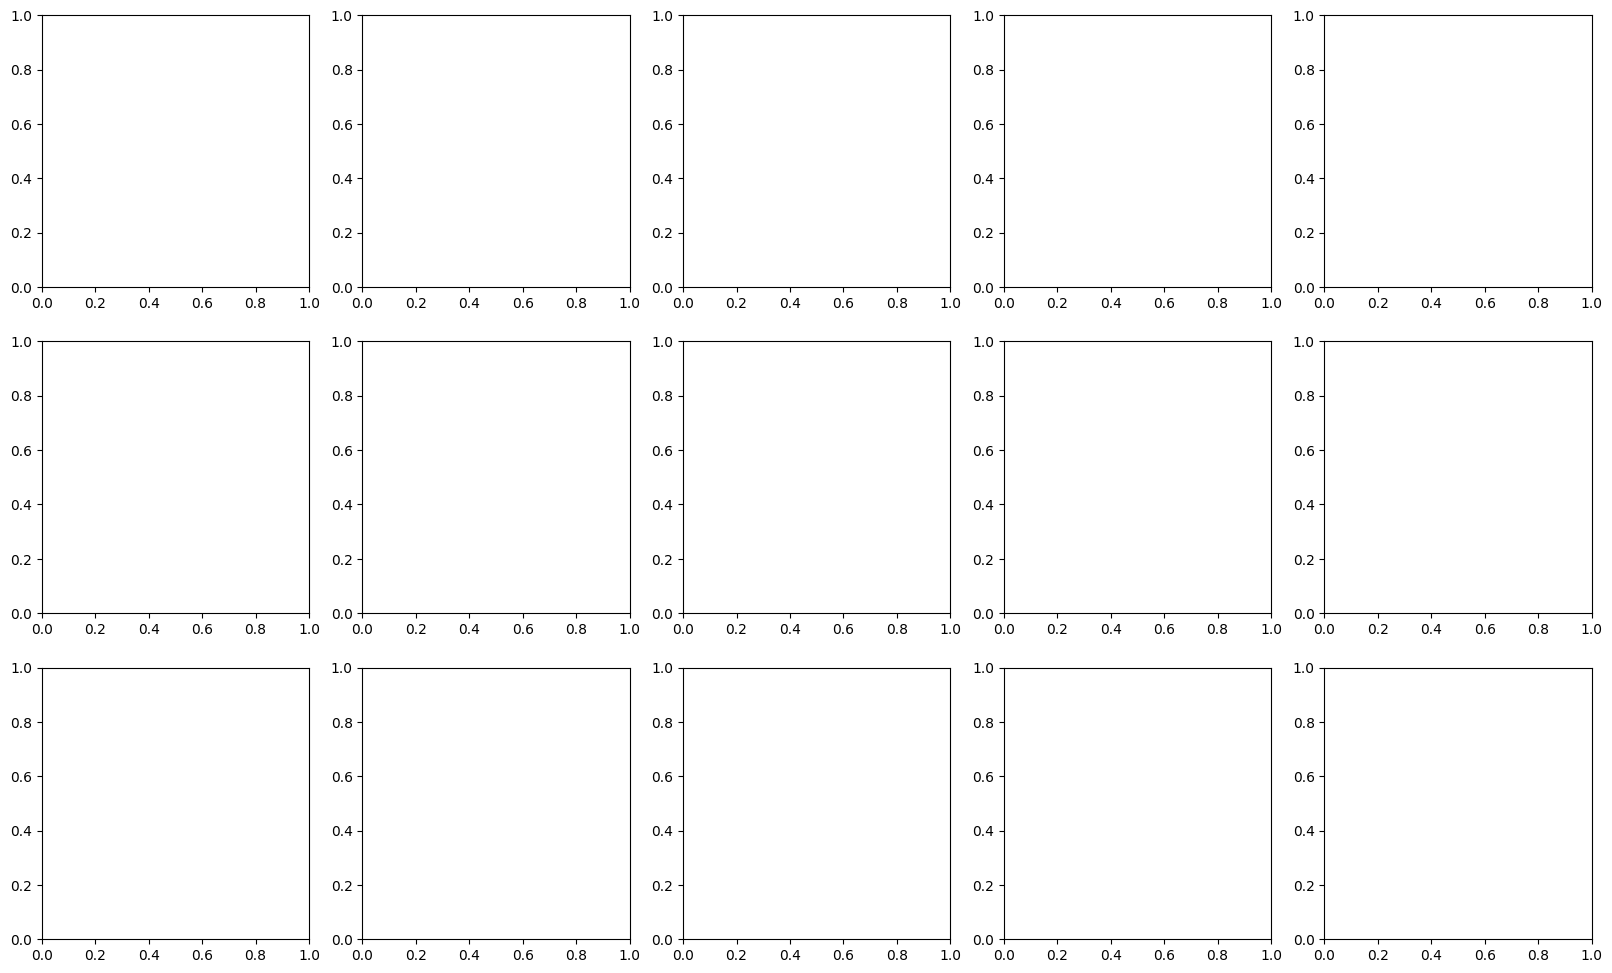

In [25]:
#Visual Comparison
import random
import matplotlib.pyplot as plt
import torch

# Define the denormalization function
def denorm(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# 1. Set all models to evaluation mode
model.eval()
model_linknet.eval()
model_deeplab.eval()

# 2. Select 3 random samples from val_ds
sample_indices = random.sample(range(len(val_ds)), 3)
fig, axs = plt.subplots(3, 5, figsize=(20, 12))

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        img_tensor, gt_mask = val_ds[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # 3b. Pass through models
        pred_unet = (model(input_tensor) > 0.5).float().squeeze().cpu().numpy()
        pred_link = (model_linknet(input_tensor) > 0.5).float().squeeze().cpu().numpy()
        pred_deep = (model_deeplab(input_tensor) > 0.5).float().squeeze().cpu().numpy()

        # 3d. Denormalize image for visualization
        vis_img = denorm(img_tensor).permute(1, 2, 0).numpy().clip(0, 1)

        # 5 & 6. Plotting
        axs[i, 0].imshow(vis_img)
        axs[i, 0].set_title("Input")

        axs[i, 1].imshow(gt_mask.squeeze().numpy(), cmap='gray')
        axs[i, 1].set_title("GT Mask")

        axs[i, 2].imshow(pred_unet, cmap='gray')
        axs[i, 2].set_title("U-Net")

        axs[i, 3].imshow(pred_link, cmap='gray')
        axs[i, 3].set_title("LinkNet")

        axs[i, 4].imshow(pred_deep, cmap='gray')
        axs[i, 4].set_title("DeepLabV3+")

        for ax in axs[i]:
            ax.axis('off')

plt.tight_layout()
plt.show()